# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Load and Inspect Data

In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df):,} rows.")

    # Check if dataset is single-asset
    unique_symbols = df['symbol'].unique()
    print(f" Unique symbols: {unique_symbols}")
    if len(unique_symbols) == 1:
        print(f" Only one symbol ({unique_symbols[0]}) found. Cross-Asset OFI cannot be computed.")

    # Compute mid-price and log returns
    df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2
    df['log_return_1m'] = np.log(df['mid_price']).diff()
    df['log_return_5m'] = np.log(df['mid_price']).diff(5)
    df['log_return_10m'] = np.log(df['mid_price']).diff(10)
    return df

# 2. Compute Best- and Multi-Level OFI

In [3]:
def compute_ofi_features(df):
    for lvl in range(10):
        bid_px = df[f'bid_px_{lvl:02d}']
        ask_px = df[f'ask_px_{lvl:02d}']
        bid_sz = df[f'bid_sz_{lvl:02d}']
        ask_sz = df[f'ask_sz_{lvl:02d}']
        ofi = [np.nan]
        for i in range(1, len(df)):
            b_contrib = (bid_sz[i] - bid_sz[i-1]) if bid_px[i] == bid_px[i-1] else (bid_sz[i] if bid_px[i] > bid_px[i-1] else -bid_sz[i-1])
            a_contrib = (ask_sz[i-1] - ask_sz[i]) if ask_px[i] == ask_px[i-1] else (-ask_sz[i-1] if ask_px[i] > ask_px[i-1] else ask_sz[i])
            ofi.append(b_contrib + a_contrib)
        df[f'ofi_level_{lvl+1}'] = ofi
    return df

# 3. Integrated OFI using PCA

In [4]:
def compute_integrated_ofi(df):
    ofi_cols = [f'ofi_level_{i+1}' for i in range(10)]
    ofi_data = df[ofi_cols].dropna()
    pca = PCA(n_components=1)
    df.loc[ofi_data.index, 'ofi_integrated'] = pca.fit_transform(ofi_data)
    return df

# 4. Lagged OFI Features

In [5]:
def create_lagged_features(df):
    lags = [1, 5, 10]
    for col in ['ofi_integrated'] + [f'ofi_level_{i+1}' for i in range(10)]:
        for lag in lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
    return df

# 5. Train LASSO Models and Summarize

In [6]:
def train_lasso_and_summarize(df):
    features = [f'{col}_lag{lag}' for col in ['ofi_integrated'] + [f'ofi_level_{i+1}' for i in range(10)] for lag in [1, 5, 10]]
    target_cols = ['log_return_1m', 'log_return_5m', 'log_return_10m']
    model_df = df[features + target_cols].dropna()

    results = {}
    scaler = StandardScaler()
    X = scaler.fit_transform(model_df[features])

    for target in target_cols:
        y = model_df[target]
        tscv = TimeSeriesSplit(n_splits=5)
        lasso = LassoCV(cv=tscv, max_iter=10000)
        lasso.fit(X, y)
        y_pred = lasso.predict(X)
        r2 = r2_score(y, y_pred)
        coefs = pd.Series(lasso.coef_, index=features)
        nonzero = coefs[coefs != 0].sort_values(key=abs, ascending=False)
        results[target] = {
            "r2": r2,
            "alpha": lasso.alpha_,
            "nonzero_coefs": nonzero
        }
    return results

# 6. Display Results Summary

In [7]:
def display_summary(results):
    summary = pd.DataFrame(columns=["Horizon", "R^2 Score", "Best Alpha", "Top Features"])
    for target, result in results.items():
        summary = pd.concat([
            summary,
            pd.DataFrame([{
                "Horizon": target,
                "R^2 Score": round(result["r2"], 4),
                "Best Alpha": round(result["alpha"], 6),
                "Top Features": ", ".join(result["nonzero_coefs"].head(5).index)
            }])
        ], ignore_index=True)

        if not result['nonzero_coefs'].empty:
            result['nonzero_coefs'].head(10).plot(kind='barh', title=f"Top LASSO Coefficients - {target}")
            plt.xlabel("Coefficient Value")
            plt.tight_layout()
            plt.show()

    return summary

# 7. Run the Full Pipeline

Loaded 5,000 rows.
 Unique symbols: ['AAPL']
 Only one symbol (AAPL) found. Cross-Asset OFI cannot be computed.


/var/folders/xx/d4y5bsbx2210fv9gdbdqc8s80000gn/T/ipykernel_16034/2520578123.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([


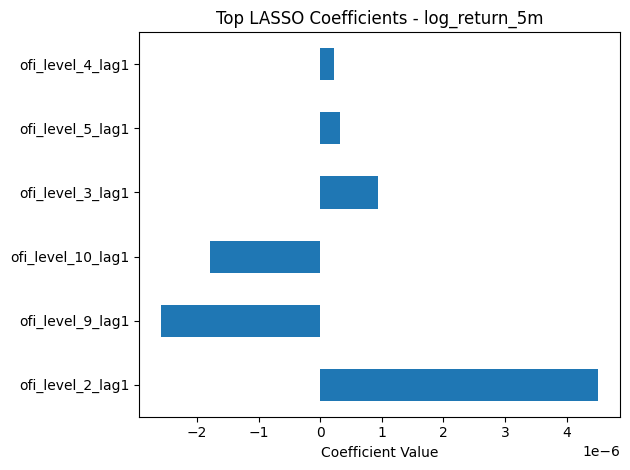

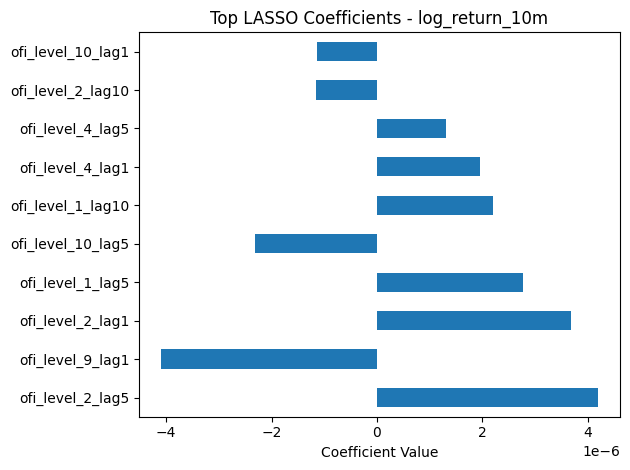


 LASSO Model Forecasting Summary:
       Horizon  R^2 Score  Best Alpha                                                                              Top Features
 log_return_1m     0.0000    0.000002                                                                                          
 log_return_5m     0.0101    0.000003 ofi_level_2_lag1, ofi_level_9_lag1, ofi_level_10_lag1, ofi_level_3_lag1, ofi_level_5_lag1
log_return_10m     0.0138    0.000003 ofi_level_2_lag5, ofi_level_9_lag1, ofi_level_2_lag1, ofi_level_1_lag5, ofi_level_10_lag5


In [8]:
if __name__ == "__main__":
    filepath = "first_25000_rows.csv"  # Update path as needed
    df = load_data(filepath)
    df = compute_ofi_features(df)
    df = compute_integrated_ofi(df)
    df = create_lagged_features(df)
    results = train_lasso_and_summarize(df)
    summary = display_summary(results)
    print("\n LASSO Model Forecasting Summary:")
    print(summary.to_string(index=False))